In [ ]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from osrs_anomaly_ml.util import features
from osrs_anomaly_ml.util.common import fill_missing_values_df, flatten_json_to_df, normalize_number, fill_missing_hiscore_data, prefix_columns, flatten_hiscore_record, read_data_dump
from osrs_anomaly_ml.util.log import get_logger
from dotenv import load_dotenv
load_dotenv(override=True)

logger = get_logger(__name__)

# make a .env file in project root or use BACKUP_IN_FILE
BACKUP_IN_FILE=os.path.join('..', 'data', 'corp_anonymized.txt')
in_file = os.getenv("NOTEBOOK_IN_FILE", BACKUP_IN_FILE)

logger.debug('reading json')
data_json = read_data_dump(in_file)
logger.debug('json loaded')


# rename rank to total rank to remove confusion with category rank
# flatten 'record' json 'property'
logger.debug('preprocess json')
data = flatten_hiscore_record(data_json)

logger.debug('flatten json into df')
df = flatten_json_to_df(data, sep="_")

logger.debug("before prefix features: " + ", ".join(sorted(df.columns)))

logger.debug('prefix columns')
df = prefix_columns(df)

logger.debug("after prefix features: " + ", ".join(sorted(df.columns)))


logger.debug('fill missing values df')
df = fill_missing_values_df(df)
# todo: add missing skills, misc and bosses
# dataset is large enough atm that there are no missing values
df = fill_missing_hiscore_data(df)

logger.debug('normalize numeric')
df = df.map(normalize_number)

# can maybe keep combat lvl float
float_cols = df.select_dtypes(include="float64").columns
float_cols = float_cols.drop("is_bot", errors="ignore")
df[float_cols] = df[float_cols].astype("int64")

df_metadata = df[["is_bot", "username"]].copy() 
df = df.set_index("username")

df

2026-06-23 13:13:55,354 - DEBUG    - reading json (3213756941.py:21)
2026-06-23 13:13:55,364 - DEBUG    - json loaded (3213756941.py:23)
2026-06-23 13:13:55,364 - DEBUG    - preprocess json (3213756941.py:28)
2026-06-23 13:13:55,365 - DEBUG    - flatten json into df (3213756941.py:31)
2026-06-23 13:13:55,427 - DEBUG    - before prefix features: category_rank, combat_lvl_value, is_bot, misc_amoxliatl_kc, misc_amoxliatl_rank, misc_araxxor_kc, misc_araxxor_rank, misc_armadyl_kc, misc_armadyl_rank, misc_artio_kc, misc_artio_rank, misc_bandos_kc, misc_bandos_rank, misc_barrows_chests_kc, misc_barrows_chests_rank, misc_bh_hunter_kc, misc_bh_hunter_rank, misc_bh_legacy_hunter_kc, misc_bh_legacy_hunter_rank, misc_bh_legacy_rogue_kc, misc_bh_legacy_rogue_rank, misc_bh_rogue_kc, misc_bh_rogue_rank, misc_brutus_kc, misc_brutus_rank, misc_bryophyta_kc, misc_bryophyta_rank, misc_callisto_kc, misc_callisto_rank, misc_calvarion_kc, misc_calvarion_rank, misc_cerberus_kc, misc_cerberus_rank, misc_cg_kc

,category_rank,is_bot,skill_overall_rank,timestamp,total_lvl,combat_lvl_value,total_xp,skill_attack_rank,skill_attack_lvl,skill_attack_xp,...,misc_bh_legacy_hunter_rank,misc_bh_legacy_hunter_kc,boss_hmt_rank,boss_hmt_kc,boss_artio_rank,boss_artio_kc,boss_shellbane_gryphon_rank,boss_shellbane_gryphon_kc,boss_spindel_rank,boss_spindel_kc
username,,,,,,,,,,,,,,,,,,,,,
######################,0,0.0,604923,2026-03-13T20:04:33.387446+00:00,1931,126,564677077,0,99,25491668,...,0,0,0,0,0,0,0,0,0,0
######################,0,0.0,1796,2026-03-13T20:04:32.546779+00:00,2376,126,1273171743,0,99,32940494,...,0,0,0,0,0,0,0,0,0,0
######################,0,0.0,227984,2026-03-13T20:04:33.344742+00:00,2167,126,750857010,0,99,137096519,...,0,0,0,0,0,0,0,0,0,0
######################,0,0.0,152069,2026-03-13T20:04:32.380160+00:00,2237,126,667792693,0,99,16790278,...,0,0,0,0,0,0,0,0,0,0
######################,0,0.0,67705,2026-03-13T20:04:33.776127+00:00,2330,126,2547247608,0,99,128043582,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
######################,0,1.0,-1,2026-03-19T12:51:26.132305+00:00,783,109,22951182,0,92,6829096,...,0,0,0,0,0,0,0,0,0,0
######################,0,1.0,1808745,2026-03-19T12:52:05.582853+00:00,1340,121,57547696,0,95,11843988,...,0,0,0,0,0,0,0,0,0,0
######################,0,0.0,-1,2026-03-19T12:52:53.651840+00:00,799,112,29324274,0,86,3852617,...,0,0,0,0,0,0,0,0,0,0


In [2]:
logger.debug('Start FE')
logger.debug('FE: add ratios')
df = features.add_username_ratio(df) # WOP
df = features.add_combat_ratio_lvl(df)
df = features.add_combat_ratio_xp(df) 
df = features.add_skill_ratios(df)
df = features.add_boss_ratios(df)

logger.debug('FE: add patterns')
df = features.add_scurrius_corp_pattern(df)

logger.debug('FE: log transform')
df = features.transform_skill_xp_to_log(df)

logger.debug('FE: Apply weights')
weights = {
    # "combat_ratio_lvl_missing_flag": 1,
}
df = features.apply_feature_weights(df, weights)

logger.debug('FE: Add soft features')
df = features.add_soft_features(
    df,
    # cols=["combat_ratio_xp_missing_flag"],
    cols=["total_lvl"],
    prefix="log_",
    method="log1p"
)

logger.debug('FE: remove columns')
df = features.remove_total_category_ranks(df)
# skills
df = features.remove_lvl(df, "skill_")
df = features.remove_xp(df, "skill_")
df = features.remove_rank(df, "skill_")

df = features.remove_lvl(df, "log_skill_")
df = features.remove_xp(df, "log_skill_")
df = features.remove_rank(df, "log_skill_")

df = features.remove_xp(df, "total_")
df = features.remove_xp(df, "log_total")
df = features.remove_xp(df, "log_combat")

# misc
df = features.remove_rank(df, "misc_")
df = features.remove_kc(df, "misc_")

# boss
df = features.remove_rank(df, "boss_")
df = features.remove_rank(df, "log_boss")
df = features.remove_kc(df, "boss_")
df = features.remove_kc(df, "log_boss")

df = df.sort_index(axis=1)

# df = features.remove(df, [
#     "combat_lvl_value", 
#     "combat_ratio_lvl_missing_flag", 
#     "combat_ratio_xp_missing_flag", 
#     "total_boss_kc",
#     "top1_boss_kc",
#     "top2_boss_kc_sum",
#     "total_lvl",
#     "xp_per_lvl",
#     "non_combat_xp",
#     "construction_vs_other_noncombat_xp_ratio",
#     ])

df = features.remove(df, [
    "nonzero_bosses",
    "total_lvl",
])



df = features.remove(df, ["is_bot"])

df

2026-06-23 13:15:12,326 - DEBUG    - Start FE (750722761.py:1)
2026-06-23 13:15:12,326 - DEBUG    - FE: add ratios (750722761.py:2)
d:\School\bap\2526-bachelorsthesis\bachproef-ml\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
2026-06-23 13:15:12,400 - DEBUG    - FE: add patterns (750722761.py:9)
2026-06-23 13:15:12,401 - DEBUG    - FE: log transform (750722761.py:12)
2026-06-23 13:15:12,403 - DEBUG    - FE: Apply weights (750722761.py:15)
2026-06-23 13:15:12,403 - DEBUG    - FE: Add soft features (750722761.py:21)
2026-06-23 13:15:12,404 - INFO     - Created soft features: ['log_total_lvl'] (features.py:268)
2026-06-23 13:15:12,404 - DEBUG    - FE: remove columns (750722761.py:30)


,boss_sparsity,combat_lvl_value,combat_ratio_lvl,combat_ratio_lvl_missing_flag,combat_ratio_xp,combat_ratio_xp_missing_flag,construction_vs_other_noncombat_xp_ratio,high_skill_xp_ratio,kc_entropy,log_total_lvl,...,skill_diversity_count,sub2_bosses_flag,timestamp,top1_boss_kc,top1_boss_ratio,top2_boss_kc_sum,top2_boss_ratio,total_boss_kc,xp_entropy,xp_per_lvl
username,,,,,,,,,,,,,,,,,,,,,
######################,0.260870,126,0.354221,0,0.956002,0,0.437146,0.458333,1.715262e-02,7.566311,...,23,0,2026-03-13T20:04:33.387446+00:00,100000,0.998034,100100,0.999032,100197,1.833472,2.924273e+05
######################,0.695652,126,0.290825,0,0.800278,0,0.050430,0.960000,1.087522e+00,7.773594,...,24,0,2026-03-13T20:04:32.546779+00:00,59456,0.791196,63107,0.839781,75147,2.506858,5.358467e+05
######################,0.782609,126,0.319797,0,0.884494,0,0.143342,0.800000,1.344004e+00,7.681560,...,24,0,2026-03-13T20:04:33.344742+00:00,47195,0.741384,49382,0.775739,63658,2.173259,3.464961e+05
######################,0.652174,126,0.306214,0,0.645628,0,0.085929,0.920000,1.284083e+00,7.713338,...,24,0,2026-03-13T20:04:32.380160+00:00,39819,0.704936,46693,0.826630,56486,2.465090,2.985215e+05
######################,0.913043,126,0.297425,0,0.365660,0,0.009190,0.920000,3.028820e+00,7.754053,...,24,0,2026-03-13T20:04:33.776127+00:00,36413,0.269160,46490,0.343647,135284,2.938705,1.093239e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
######################,0.014493,109,0.675607,0,0.865608,0,53.591958,0.250000,-1.000000e-09,6.664409,...,19,1,2026-03-19T12:51:26.132305+00:00,76,1.000000,76,1.000000,76,1.725145,2.931185e+04
######################,0.028986,121,0.471642,0,0.918787,0,0.007853,0.250000,5.367496e-01,7.201171,...,23,1,2026-03-19T12:52:05.582853+00:00,1792,0.772081,2321,1.000000,2321,1.958899,4.294604e+04
######################,0.014493,112,0.680851,0,0.897049,0,57.442473,0.238095,-1.000000e-09,6.684612,...,20,1,2026-03-19T12:52:53.651840+00:00,833,1.000000,833,1.000000,833,1.666853,3.670122e+04


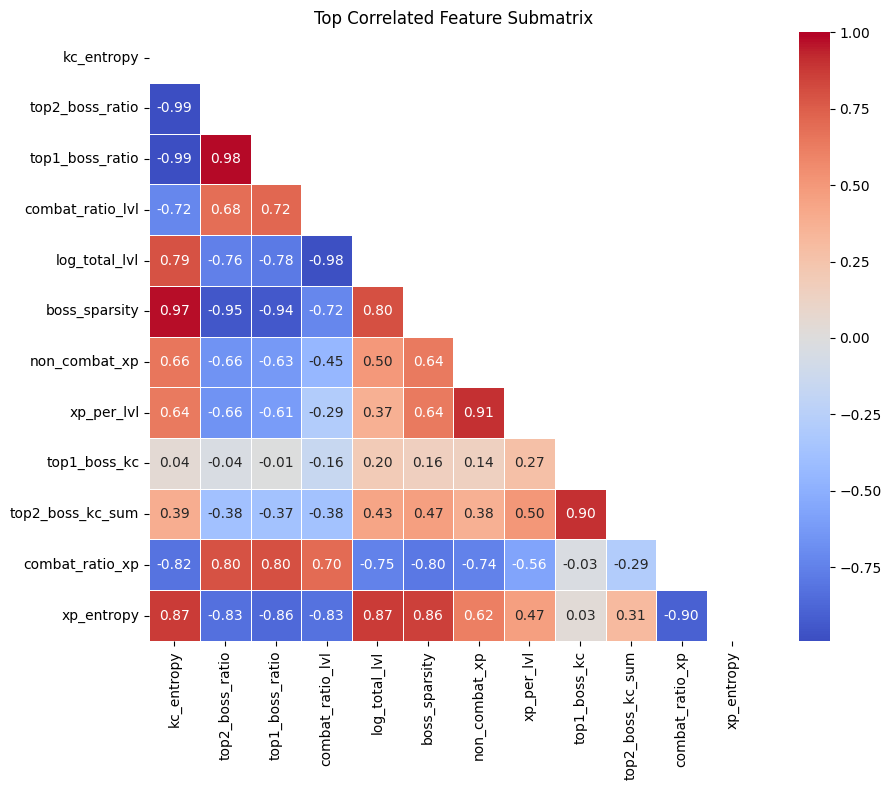

In [3]:
corr = df.drop(columns=['timestamp']).corr()

# mask self-correlations + duplicate pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# stack and get absolute correlations
corr_pairs = upper.abs().stack()

# top 10 pairs + features from top pairs
top10 = corr_pairs.sort_values(ascending=False).head(10)
top_features = list(dict.fromkeys([i for pair in top10.index for i in pair]))

subset_corr = corr.loc[top_features, top_features]
mask = np.triu(np.ones_like(subset_corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    subset_corr, 
    mask=mask, 
    cmap="coolwarm", 
    vmax=1, 
    center=0,
    square=True, 
    linewidths=0.5, 
    annot=True, 
    fmt=".2f"
)
plt.title("Top Correlated Feature Submatrix")
plt.tight_layout()
display(plt.gcf())
plt.close()

In [4]:
df

,boss_sparsity,combat_lvl_value,combat_ratio_lvl,combat_ratio_lvl_missing_flag,combat_ratio_xp,combat_ratio_xp_missing_flag,construction_vs_other_noncombat_xp_ratio,high_skill_xp_ratio,kc_entropy,log_total_lvl,...,skill_diversity_count,sub2_bosses_flag,timestamp,top1_boss_kc,top1_boss_ratio,top2_boss_kc_sum,top2_boss_ratio,total_boss_kc,xp_entropy,xp_per_lvl
username,,,,,,,,,,,,,,,,,,,,,
######################,0.260870,126,0.354221,0,0.956002,0,0.437146,0.458333,1.715262e-02,7.566311,...,23,0,2026-03-13T20:04:33.387446+00:00,100000,0.998034,100100,0.999032,100197,1.833472,2.924273e+05
######################,0.695652,126,0.290825,0,0.800278,0,0.050430,0.960000,1.087522e+00,7.773594,...,24,0,2026-03-13T20:04:32.546779+00:00,59456,0.791196,63107,0.839781,75147,2.506858,5.358467e+05
######################,0.782609,126,0.319797,0,0.884494,0,0.143342,0.800000,1.344004e+00,7.681560,...,24,0,2026-03-13T20:04:33.344742+00:00,47195,0.741384,49382,0.775739,63658,2.173259,3.464961e+05
######################,0.652174,126,0.306214,0,0.645628,0,0.085929,0.920000,1.284083e+00,7.713338,...,24,0,2026-03-13T20:04:32.380160+00:00,39819,0.704936,46693,0.826630,56486,2.465090,2.985215e+05
######################,0.913043,126,0.297425,0,0.365660,0,0.009190,0.920000,3.028820e+00,7.754053,...,24,0,2026-03-13T20:04:33.776127+00:00,36413,0.269160,46490,0.343647,135284,2.938705,1.093239e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
######################,0.014493,109,0.675607,0,0.865608,0,53.591958,0.250000,-1.000000e-09,6.664409,...,19,1,2026-03-19T12:51:26.132305+00:00,76,1.000000,76,1.000000,76,1.725145,2.931185e+04
######################,0.028986,121,0.471642,0,0.918787,0,0.007853,0.250000,5.367496e-01,7.201171,...,23,1,2026-03-19T12:52:05.582853+00:00,1792,0.772081,2321,1.000000,2321,1.958899,4.294604e+04
######################,0.014493,112,0.680851,0,0.897049,0,57.442473,0.238095,-1.000000e-09,6.684612,...,20,1,2026-03-19T12:52:53.651840+00:00,833,1.000000,833,1.000000,833,1.666853,3.670122e+04
